In [1]:
from pathlib import Path
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# import necessary functions/models from sklearn
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error , mean_absolute_error 
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

# import xgboost regressor from xgboost
from xgboost import XGBRegressor

# import hyperparameter tuners from optuna
import optuna
from optuna import create_study
from optuna.samplers import TPESampler  # Bayesian/TPE sampler


from src.data_utils.preprocessing import (
    PreprocessingConfig,
    prepare_train_test_split,
    get_correlated_features,
    plot_hist_grid
)

config = PreprocessingConfig(
    # adjust if your column names differ
    date_col="Date",
    store_col="Store",
    target_col="Sales",
    lags=(1, 7, 14, 28, 365),
)

> 📦 **Data Prep:** Load train/test sets plus the fitted X and y scalers via the preprocessing module here.

In [2]:
train, test, x_scaler, y_scaler = prepare_train_test_split(
    train_path=Path("data/train.csv"),
    store_path=Path("data/store.csv"),
    config=config
)

d:\FIU\CAP 3764 Advanced Data Science\CAP_3764_2025_Fall_Team_2\src\data_utils\preprocessing.py:78: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(Path(path))


> 💾 **Save Artifacts:** Persist the fitted scalers now so they can be reused later.

In [3]:
joblib.dump(x_scaler, Path("artifacts/x_scaler.joblib"))
joblib.dump(y_scaler, Path("artifacts/y_scaler.joblib"))

['artifacts\\y_scaler.joblib']

> 🔍 **Data Check:** Inspect the train dataset here to confirm everything looks correct.

In [4]:
train.describe()

,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceYear,Promo2,...,sqrt_Sales_lag1,sqrt_Customers_lag1,sqrt_Sales_lag7,sqrt_Customers_lag7,sqrt_Sales_lag14,sqrt_Customers_lag14,sqrt_Sales_lag28,sqrt_Customers_lag28,sqrt_Sales_lag365,sqrt_Customers_lag365
count,758389.000000,7.583890e+05,7.583890e+05,758389.000000,758389.000000,758389.000000,758389.000000,7.564310e+05,758389.000000,758389.000000,...,7.572740e+05,7.572740e+05,7.505840e+05,7.505840e+05,7.427790e+05,7.427790e+05,7.271690e+05,7.271690e+05,3.514140e+05,3.514140e+05
mean,4.003701,1.678944e-17,-9.713890e-17,0.831360,0.380583,0.028285,0.182874,1.532996e-17,1369.726969,0.498644,...,-9.487990e-17,-4.263590e-16,-2.447666e-16,3.453391e-16,-3.550901e-16,-2.877454e-17,-2.814151e-16,-3.314444e-16,-1.630503e-16,-1.811670e-16
std,1.998456,1.000001e+00,1.000001e+00,0.374434,0.485531,0.165786,0.386564,1.000001e+00,935.881626,0.499998,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,1.000000,-1.499204e+00,-1.363769e+00,0.000000,0.000000,0.000000,0.000000,-7.009207e-01,-1.000000,0.000000,...,-1.972289e+00,-1.931916e+00,-1.965717e+00,-1.925209e+00,-1.965383e+00,-1.924717e+00,-1.962899e+00,-1.922737e+00,-1.986744e+00,-1.942488e+00
25%,2.000000,-5.322138e-01,-4.970486e-01,1.000000,0.000000,0.000000,0.000000,-6.115947e-01,-1.000000,0.000000,...,-1.947954e-01,-1.964736e-01,-1.935817e-01,-1.961936e-01,-1.931122e-01,-1.948454e-01,-1.941218e-01,-1.966056e-01,-1.984443e-01,-2.072234e-01
50%,4.000000,-1.067914e-02,-5.401056e-02,1.000000,0.000000,0.000000,0.000000,-4.018729e-01,2006.000000,0.000000,...,2.308390e-01,2.005613e-01,2.331382e-01,2.029030e-01,2.331180e-01,2.027001e-01,2.325860e-01,2.027255e-01,2.298558e-01,1.986486e-01
75%,6.000000,5.389260e-01,4.384929e-01,1.000000,1.000000,0.000000,0.000000,1.884551e-01,2011.000000,1.000000,...,6.051031e-01,5.690079e-01,6.060565e-01,5.696647e-01,6.055633e-01,5.684082e-01,6.059292e-01,5.695886e-01,6.055980e-01,5.676551e-01
max,7.000000,8.479474e+00,1.452538e+01,1.000000,1.000000,1.000000,1.000000,9.117167e+00,2015.000000,1.000000,...,3.729946e+00,5.489434e+00,3.733998e+00,5.487028e+00,3.740980e+00,5.491191e+00,3.737654e+00,5.486356e+00,3.662666e+00,5.515115e+00


In [5]:
print(sorted(train.columns))

['Assortment', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'Competition_open_since_August', 'Competition_open_since_December', 'Competition_open_since_February', 'Competition_open_since_January', 'Competition_open_since_July', 'Competition_open_since_June', 'Competition_open_since_March', 'Competition_open_since_May', 'Competition_open_since_November', 'Competition_open_since_October', 'Competition_open_since_September', 'Customers', 'Customers_lag1', 'Customers_lag14', 'Customers_lag28', 'Customers_lag365', 'Customers_lag7', 'Day', 'DayOfWeek', 'Month', 'Open', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Promo2_Interval_in_Aug', 'Promo2_Interval_in_Dec', 'Promo2_Interval_in_Feb', 'Promo2_Interval_in_Jan', 'Promo2_Interval_in_Jul', 'Promo2_Interval_in_Jun', 'Promo2_Interval_in_Mar', 'Promo2_Interval_in_May', 'Promo2_Interval_in_Nov', 'Promo2_Interval_in_Oct', 'Promo2_Interval_in_Sept', 'Sales', 'Sales_lag1', 'Sales_lag14', 'Sales_lag28', 'Sales_lag365', 'Sales_lag7

In [6]:
cols_not_to_use = ['Store', 'Customers', 'Sales']

In [7]:
def format_correlated(features, title="Correlated Features"):
    if not features:
        return f"{title}:\n  (none)\n"
    bullet = "\n".join(f"  • {name}" for name in features)
    return f"{title} ({len(features)}):\n{bullet}\n"

In [8]:
#num_feats = train.select_dtypes(include = 'float64').columns
corr_cols, corr_df = get_correlated_features(train[[c for c in train.columns if c not in cols_not_to_use]], target_col= 'sqrt_Sales', threshold=config.corr_threshold)
print(format_correlated(corr_cols, title="High-correlation columns with target feature"))

High-correlation columns with target feature (16):
  • Sales_lag1
  • Customers_lag1
  • Sales_lag7
  • Customers_lag7
  • Sales_lag14
  • Customers_lag14
  • Sales_lag28
  • Customers_lag28
  • Sales_lag365
  • Customers_lag365
  • sqrt_Sales_lag7
  • sqrt_Customers_lag7
  • sqrt_Sales_lag14
  • sqrt_Customers_lag14
  • sqrt_Sales_lag28
  • sqrt_Customers_lag28



In [9]:
corr_df

,Feature,Correlation
0,sqrt_Sales_lag14,0.804016
1,sqrt_Sales_lag28,0.800672
2,sqrt_Customers_lag28,0.783873
3,sqrt_Customers_lag14,0.782862
4,sqrt_Customers_lag7,0.757718
5,sqrt_Sales_lag7,0.754371
6,Sales_lag14,0.753541
7,Sales_lag28,0.744472
8,Customers_lag14,0.690614
9,Customers_lag28,0.688844


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 758389 entries, 2013-01-01 to 2014-12-07
Data columns (total 61 columns):
 #   Column                            Non-Null Count   Dtype   
---  ------                            --------------   -----   
 0   Store                             758389 non-null  category
 1   DayOfWeek                         758389 non-null  int64   
 2   Sales                             758389 non-null  float64 
 3   Customers                         758389 non-null  float64 
 4   Open                              758389 non-null  int64   
 5   Promo                             758389 non-null  int64   
 6   StateHoliday                      758389 non-null  int64   
 7   SchoolHoliday                     758389 non-null  int64   
 8   StoreType                         758389 non-null  object  
 9   Assortment                        758389 non-null  object  
 10  CompetitionDistance               756431 non-null  float64 
 11  CompetitionOpenSinceYea

In [11]:
selected_columns = train.select_dtypes(include = 'int64').columns.tolist() + ['Store'] + corr_cols + ['sqrt_Sales']

In [12]:
train = train[selected_columns]
test = test[selected_columns]

> ❌ **Warning:** The following block is compute-intensive and may take a while. It fits an unoptimized RandomForest on the full training set to extract feature importances for feature selection.

In [13]:
rs = 42
rf = RandomForestRegressor(random_state= rs, verbose = 1, n_jobs= -1)
rf.fit(X= train.drop(columns = ['Store', 'sqrt_Sales']), y= train['sqrt_Sales'].values.ravel())

importances = rf.feature_importances_
for name, imp in sorted(zip(train.drop(columns = ['Store', 'sqrt_Sales']).columns, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.7min finished


Open: 0.7847
Sales_lag14: 0.0612
sqrt_Sales_lag14: 0.0539
Sales_lag1: 0.0243
sqrt_Sales_lag28: 0.0161
Sales_lag28: 0.0160
Promo: 0.0078
sqrt_Sales_lag7: 0.0069
Sales_lag7: 0.0068
DayOfWeek: 0.0053
Customers_lag1: 0.0028
Sales_lag365: 0.0016
sqrt_Customers_lag7: 0.0016
Customers_lag7: 0.0015
Customers_lag28: 0.0010
sqrt_Customers_lag28: 0.0010
CompetitionOpenSinceYear: 0.0010
Customers_lag365: 0.0009
Customers_lag14: 0.0008
sqrt_Customers_lag14: 0.0008
SchoolHoliday: 0.0008
Promo2SinceWeek: 0.0006
Promo2SinceYear: 0.0005
StateHoliday: 0.0002
Competition_open_since_September: 0.0002
Competition_open_since_November: 0.0001
Competition_open_since_March: 0.0001
Competition_open_since_October: 0.0001
Competition_open_since_July: 0.0001
Competition_open_since_June: 0.0001
Competition_open_since_December: 0.0001
Competition_open_since_May: 0.0001
Competition_open_since_February: 0.0001
Competition_open_since_August: 0.0001
Promo2_Interval_in_Jan: 0.0001
Promo2_Interval_in_Jul: 0.0001
Promo2_In

> 🌟 **Feature Spotlight:** Let's reveal the most important features according to the Random Forest.

In [14]:
names = train.drop(columns=['Store', 'sqrt_Sales']).columns
imp_df = pd.DataFrame({"feature": names, "importance": rf.feature_importances_})
imp_df = imp_df.sort_values("importance", ascending=False)
imp_df["cum_importance"] = imp_df["importance"].cumsum()

selected = imp_df.loc[imp_df["cum_importance"] <= 0.975, "feature"].tolist()
print("Selected:", selected)

Selected: ['Open', 'Sales_lag14', 'sqrt_Sales_lag14', 'Sales_lag1', 'sqrt_Sales_lag28', 'Sales_lag28', 'Promo', 'sqrt_Sales_lag7']


In [15]:
tscv = TimeSeriesSplit(n_splits= 5)

# Just to make sure the tiem series split is working
for i, (train_idx, test_idx) in enumerate(tscv.split(train), 1):
    print(f"Split {i}:")
    print(f"train rows={len(train_idx)}, test rows={len(test_idx)}")
    print(f"Train Min date: {train.iloc[train_idx].index.min()} , Train Max date: {train.iloc[train_idx].index.max()}")
    print(f"Test Min date: {train.iloc[test_idx].index.min()} , Test Max date: {train.iloc[test_idx].index.max()}")
    print("="*70)


Split 1:
train rows=126399, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-04-24 00:00:00
Test Min date: 2013-04-24 00:00:00 , Test Max date: 2013-08-15 00:00:00
Split 2:
train rows=252797, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-08-15 00:00:00
Test Min date: 2013-08-15 00:00:00 , Test Max date: 2013-12-07 00:00:00
Split 3:
train rows=379195, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2013-12-07 00:00:00
Test Min date: 2013-12-07 00:00:00 , Test Max date: 2014-03-30 00:00:00
Split 4:
train rows=505593, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2014-03-30 00:00:00
Test Min date: 2014-03-30 00:00:00 , Test Max date: 2014-07-25 00:00:00
Split 5:
train rows=631991, test rows=126398
Train Min date: 2013-01-01 00:00:00 , Train Max date: 2014-07-25 00:00:00
Test Min date: 2014-07-25 00:00:00 , Test Max date: 2014-12-07 00:00:00


> 🧭 **Feature Set Build:** Create the train and test datasets here using the most important features for model training.

In [16]:
rmse = make_scorer(mean_squared_error)

# drop na rows in the datasets (they are present due to the lagged features)
train = train.dropna()
test = test.dropna()

X_train = train[selected]
y_train = train['sqrt_Sales'].values.ravel()

X_test = test[selected]
y_test = test['sqrt_Sales'].values.ravel()

In [17]:
# objective function to train Elastic Net using time series cross validation and optuna hyperparameter tuning
def objective_elastic(trial):
    model = ElasticNet(
        alpha=trial.suggest_float("alpha", 1e-4, 1e2, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
        max_iter=5000,
        random_state=rs,
    )
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=rmse)
    return scores.mean()

In [18]:
# objective function to train Random Forest using time series cross validation and optuna hyperparameter tuning
def objective_rf(trial):
    model = RandomForestRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 600),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        n_jobs=-1,
        random_state=rs,
        verbose=0,
    )
    scores = cross_val_score(model, X_train, y_train, cv=tscv, scoring=rmse)
    return scores.mean()

In [19]:
# objective function to train XGBoost using time series cross validation and optuna hyperparameter tuning
def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 800),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-6, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-6, 5.0, log=True),
        min_child_weight=trial.suggest_float("min_child_weight", 1e-3, 5.0, log=True),
        tree_method="hist",
        random_state=rs,
    )
    scores = cross_val_score(model, X_train, y_train,  cv=tscv, scoring=rmse)
    return scores.mean()

In [20]:
# function to define "study" or optimization process
def run_study(name, objective, n_trials=30):
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
        study_name=name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"{name} best RMSE: {study.best_value:.4f}")
    print(f"{name} best params: {study.best_params}")
    return study

>🚦 **Model Tuning:** The next blocks run cross-validation and hyperparameter optimization on the train dataset for ElasticNet, Random Forest, and XGBoost.

In [21]:
study_elastic = run_study("ElasticNet", objective_elastic)

[I 2025-11-30 01:47:48,256] A new study created in memory with name: ElasticNet
[I 2025-11-30 01:47:48,499] Trial 0 finished with value: 0.0982951304357439 and parameters: {'alpha': 0.017670169402947963, 'l1_ratio': 0.9507143064099162}. Best is trial 0 with value: 0.0982951304357439.
[I 2025-11-30 01:47:48,695] Trial 1 finished with value: 1.0148697160569464 and parameters: {'alpha': 2.465832945854912, 'l1_ratio': 0.5986584841970366}. Best is trial 0 with value: 0.0982951304357439.
[I 2025-11-30 01:47:49,499] Trial 2 finished with value: 0.06572948473364579 and parameters: {'alpha': 0.0008632008168602544, 'l1_ratio': 0.15599452033620265}. Best is trial 2 with value: 0.06572948473364579.
[I 2025-11-30 01:47:50,280] Trial 3 finished with value: 0.064832558318954 and parameters: {'alpha': 0.00022310108018679258, 'l1_ratio': 0.8661761457749352}. Best is trial 3 with value: 0.064832558318954.
[I 2025-11-30 01:47:50,536] Trial 4 finished with value: 0.39973973643294125 and parameters: {'alph

ElasticNet best RMSE: 0.0647
ElasticNet best params: {'alpha': 0.00010486754331731991, 'l1_ratio': 0.659634969150275}


In [22]:
study_rf = run_study("RandomForest", objective_rf)

[I 2025-11-30 01:48:06,102] A new study created in memory with name: RandomForest
[I 2025-11-30 01:50:12,713] Trial 0 finished with value: 0.034766650744825975 and parameters: {'n_estimators': 287, 'max_depth': 20, 'max_features': 0.8123957592679836, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.034766650744825975.
[I 2025-11-30 01:50:24,683] Trial 1 finished with value: 0.06040260962854003 and parameters: {'n_estimators': 178, 'max_depth': 6, 'max_features': 0.3406585285177396, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.034766650744825975.
[I 2025-11-30 01:51:20,606] Trial 2 finished with value: 0.04158309099651823 and parameters: {'n_estimators': 401, 'max_depth': 16, 'max_features': 0.3144091460070617, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.034766650744825975.
[I 2025-11-30 01:52:11,297] Trial 3 finished with value: 0.04677271622935984 and parameters: {'n_estimators': 517, 'max_depth': 7, 'max_features': 0.42727747704497043, 'min_samples_leaf': 1}. 

RandomForest best RMSE: 0.0340
RandomForest best params: {'n_estimators': 540, 'max_depth': 14, 'max_features': 0.7778419131815916, 'min_samples_leaf': 4}


In [23]:
study_xgb = run_study("XGBRegressor", objective_xgb)

[I 2025-11-30 02:40:15,386] A new study created in memory with name: XGBRegressor
[I 2025-11-30 02:40:33,675] Trial 0 finished with value: 0.037908701112438645 and parameters: {'n_estimators': 425, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 8.629132190071855e-06, 'reg_lambda': 2.4496293433163567e-06, 'min_child_weight': 1.599409170128044}. Best is trial 0 with value: 0.037908701112438645.
[I 2025-11-30 02:40:50,424] Trial 1 finished with value: 0.0338549002702777 and parameters: {'n_estimators': 561, 'max_depth': 8, 'learning_rate': 0.010636066512540286, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'reg_alpha': 1.879466824163847e-05, 'reg_lambda': 1.6521139617131478e-05, 'min_child_weight': 0.004768785415482609}. Best is trial 1 with value: 0.0338549002702777.
[I 2025-11-30 02:41:00,132] Trial 2 finished with value: 0.033753296405404254 and parameters: {'n_estim

XGBRegressor best RMSE: 0.0317
XGBRegressor best params: {'n_estimators': 504, 'max_depth': 4, 'learning_rate': 0.03353807743508302, 'subsample': 0.7051279270954192, 'colsample_bytree': 0.9505252307022191, 'reg_alpha': 6.322638864672485e-05, 'reg_lambda': 0.08757074917603794, 'min_child_weight': 0.061568669670223605}


> ✅ **Post-Tuning Fit:** With cross-validation and hyperparameter optimization done, pull the best hyperparameters and fit the prototype model on the full train dataset.

In [24]:
best_elastic = ElasticNet(**study_elastic.best_params, max_iter=5000, random_state=42)
best_elastic.fit(X_train, y_train)

,alpha,0.00010486754331731991
,l1_ratio,0.659634969150275
,fit_intercept,True
,precompute,False
,max_iter,5000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,42
,selection,'cyclic'


In [25]:
best_rf = RandomForestRegressor(**study_rf.best_params, n_jobs=-1, random_state=42)
best_rf.fit(X_train, y_train)

,n_estimators,540
,criterion,'squared_error'
,max_depth,14
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,0.7778419131815916
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
best_xgb = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9505252307022191
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


> 📊 **Model Evaluation:** Visualize predictions and error metrics for both train and test datasets here.

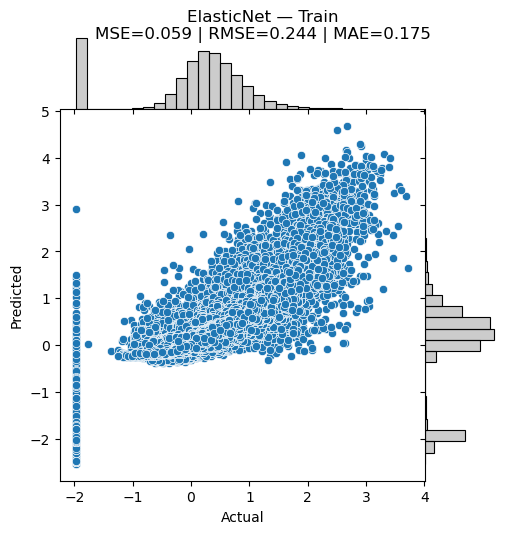

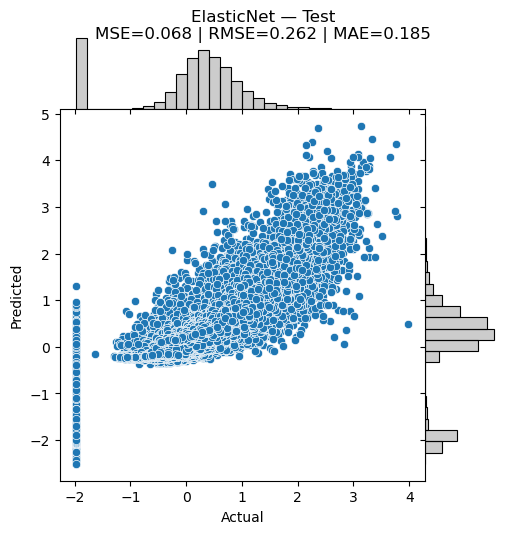

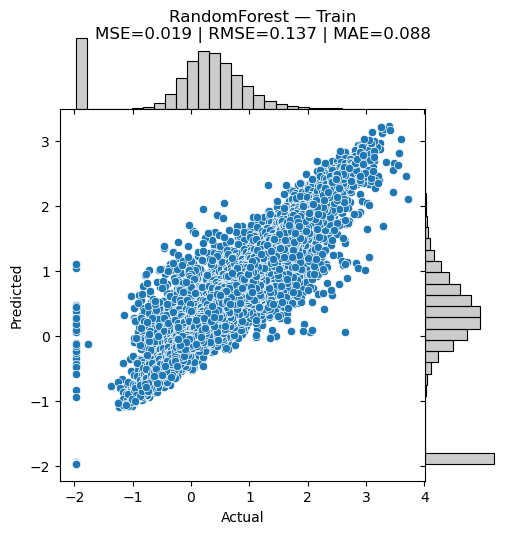

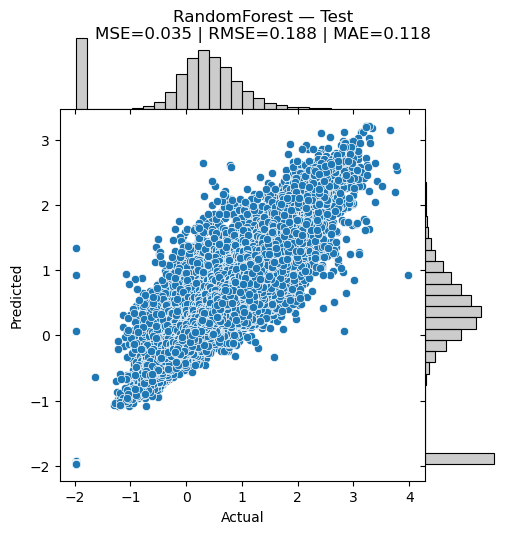

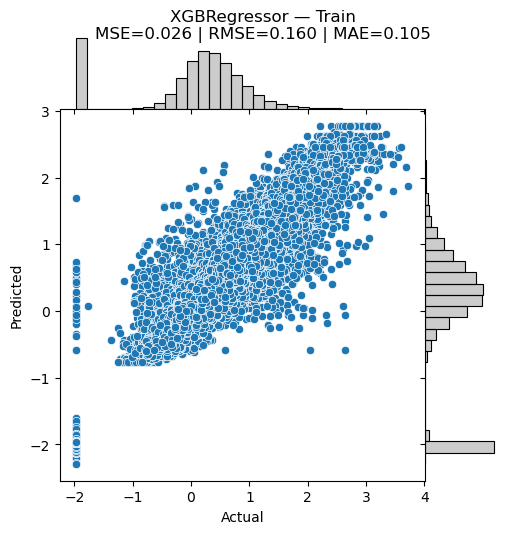

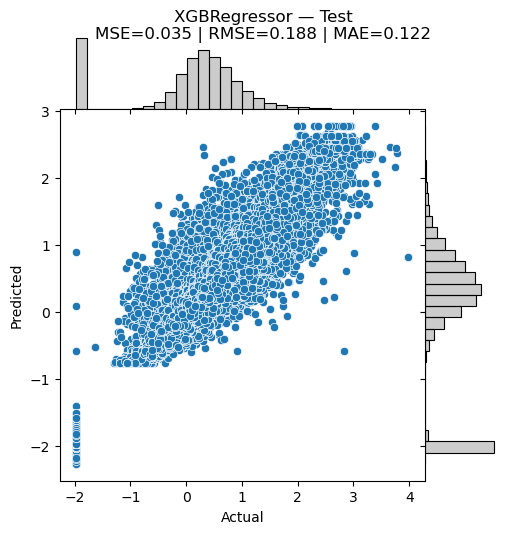

In [27]:
models = [
    ("ElasticNet", best_elastic),
    ("RandomForest", best_rf),
    ("XGBRegressor", best_xgb),
]

splits = [("Train", X_train, y_train), ("Test", X_test, y_test)]

for name, model in models:
    for split_name, X_split, y_split in splits:
        y_pred = model.predict(X_split)
        mse = mean_squared_error(y_split, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_split, y_pred)
        g = sns.jointplot(
            x=y_split,
            y=y_pred,
            kind="scatter",
            height=5,
            space=0,
            marginal_kws={"bins": 30, "fill": True, "color": "gray", "alpha": 0.4},
        )
        g.set_axis_labels("Actual", "Predicted")
        g.figure.suptitle(f"{name} — {split_name}\nMSE={mse:.3f} | RMSE={rmse:.3f} | MAE={mae:.3f}", y=1.02)

> 💾 **Save Models:** Finally, save the trained models for future use.

In [28]:
joblib.dump(best_elastic, Path("models/prototype_elasticnet.joblib"))
joblib.dump(best_rf, Path("models/prototype_random_forest.joblib"))
joblib.dump(best_xgb, Path("models/prototype_xgb_regressor.joblib"))

['models\\prototype_xgb_regressor.joblib']